In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import multiprocessing
from functools import partial

np.random.seed(42)

In [2]:
class MWUAgent:
    def __init__(self, num_bids):
        self.num_bids = num_bids
        self.weights = np.ones(num_bids)

    def get_strategy(self):
        return self.weights / np.sum(self.weights)

    def update(self, utilities, eta):
        shifted_u = utilities - np.max(utilities)
        self.weights = self.weights * np.exp(eta * shifted_u)

class NoSwapRegretAgent:
    def __init__(self, num_bids):
        self.num_bids = num_bids
        self.weights = np.ones((num_bids, num_bids))
        self.last_q = np.ones(num_bids) / num_bids

    def get_strategy(self):
        P = self.weights / self.weights.sum(axis=1, keepdims=True)
        q = self.last_q.copy()
        for _ in range(500):
            q_new = q @ P
            if np.max(np.abs(q_new - q)) < 1e-12:
                break
            q = q_new
        q = np.maximum(q_new, 0)
        q_sum = q.sum()
        q = q / q_sum if q_sum > 0 else np.ones(self.num_bids) / self.num_bids

        self.last_q = q
        return q

    def update(self, utilities, eta):
        shifted_u = utilities - np.max(utilities)
        self.weights *= np.exp(eta * np.outer(self.last_q, shifted_u))

def simulate_auction(v1, v2, V, learning_rates, auction_type='first', algo1='MWU', algo2='MWU', verbose=1, every=10000, learning_rates_2=None):
    bids = np.array([i / V for i in range(1, V + 1)])
    num_bids = len(bids)

    agent1 = MWUAgent(num_bids) if algo1 == 'MWU' else NoSwapRegretAgent(num_bids)
    agent2 = MWUAgent(num_bids) if algo2 == 'MWU' else NoSwapRegretAgent(num_bids)

    history = {
        'round': [], 'winner': [], 'winning_bid': [], 'payment': [],
        'bid1': [], 'bid2': [],
        'external_regret1': [], 'external_regret2': [],
        'swap_regret1': [],    'swap_regret2': []
    }

    cum_u1 = np.zeros(num_bids)         
    cum_u2 = np.zeros(num_bids)
    cum_actual_u1 = 0.0                
    cum_actual_u2 = 0.0
    swap_u1 = np.zeros((num_bids, num_bids))
    swap_u2 = np.zeros((num_bids, num_bids))

    for t, eta in enumerate(learning_rates):
        if t % every == 0 and verbose:
            print(f"Round {t}")

        p1 = agent1.get_strategy()
        p2 = agent2.get_strategy()

        b1 = np.random.choice(bids, p=p1)
        b2 = np.random.choice(bids, p=p2)

        # Index of the chosen bid in the bids array
        idx1 = np.searchsorted(bids, b1)
        idx2 = np.searchsorted(bids, b2)

        if b1 > b2:
            winner, winning_bid, payment = 1, b1, b1 if auction_type == 'first' else b2
        elif b2 > b1:
            winner, winning_bid, payment = 2, b2, b2 if auction_type == 'first' else b1
        else:
            winner = np.random.choice([1, 2])
            winning_bid, payment = b1, b1 if auction_type == 'first' else b2

        u1 = np.zeros(num_bids)
        u2 = np.zeros(num_bids)

        for i, b in enumerate(bids):
            if b > b2:
                u1[i] = v1 - (b if auction_type == 'first' else b2)
            elif b == b2:
                u1[i] = 0.5 * (v1 - (b if auction_type == 'first' else b2))

            if b > b1:
                u2[i] = v2 - (b if auction_type == 'first' else b1)
            elif b == b1:
                u2[i] = 0.5 * (v2 - (b if auction_type == 'first' else b1))

        cum_u1 += u1
        cum_u2 += u2
        cum_actual_u1 += u1[idx1]
        cum_actual_u2 += u2[idx2]
        swap_u1[idx1] += u1 
        swap_u2[idx2] += u2

        T = t + 1
        external_regret1 = (np.max(cum_u1) - cum_actual_u1) / T
        external_regret2 = (np.max(cum_u2) - cum_actual_u2) / T

        swap_regret1 = np.sum(np.maximum(0, np.max(swap_u1, axis=1) - np.diag(swap_u1))) / T
        swap_regret2 = np.sum(np.maximum(0, np.max(swap_u2, axis=1) - np.diag(swap_u2))) / T

        history['round'].append(T)
        history['winner'].append(f"Bidder {winner}")
        history['winning_bid'].append(winning_bid)
        history['payment'].append(payment)
        history['bid1'].append(b1)
        history['bid2'].append(b2)
        history['external_regret1'].append(external_regret1)
        history['external_regret2'].append(external_regret2)
        history['swap_regret1'].append(swap_regret1)
        history['swap_regret2'].append(swap_regret2)

        agent1.update(u1, eta)
        if learning_rates_2 is not None:
            agent2.update(u2, learning_rates_2[t])
        else:
            agent2.update(u2, eta)

    return pd.DataFrame(history)

In [3]:
V = 100                  
v1 = V / V              
v2 = 50 / V      

T = 20000000
every = T / 20
etas = [0.1 / np.sqrt(t) for t in range(1, T + 1)]
df_spa_bm = simulate_auction(
    learning_rates=etas, 
    v1=v1, v2=v2, V=V, 
    auction_type='second', 
    algo1='BM', 
    algo2='BM', 
    every=every)

Round 0
Round 1000000
Round 2000000
Round 3000000
Round 4000000
Round 5000000
Round 6000000
Round 7000000
Round 8000000
Round 9000000
Round 10000000
Round 11000000
Round 12000000
Round 13000000
Round 14000000
Round 15000000
Round 16000000
Round 17000000
Round 18000000
Round 19000000


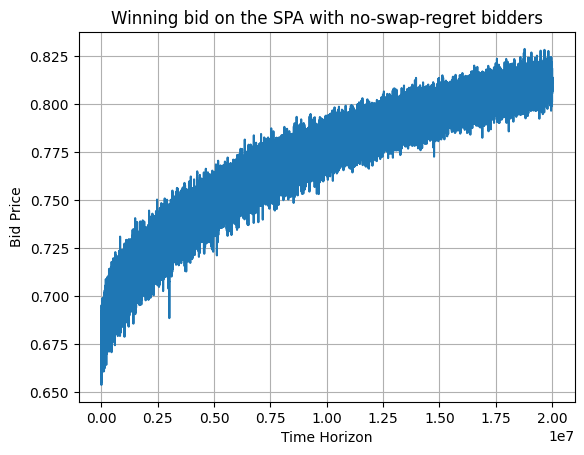

In [7]:
window = 1000
rolling_avg = df_spa_bm['winning_bid'].rolling(window).mean()
plt.plot(range(T), rolling_avg)
plt.title(f'Winning bid on the SPA with no-swap-regret bidders')
plt.xlabel("Time Horizon")
plt.ylabel("Bid Price")
plt.grid()

Text(0, 0.5, 'Counts')

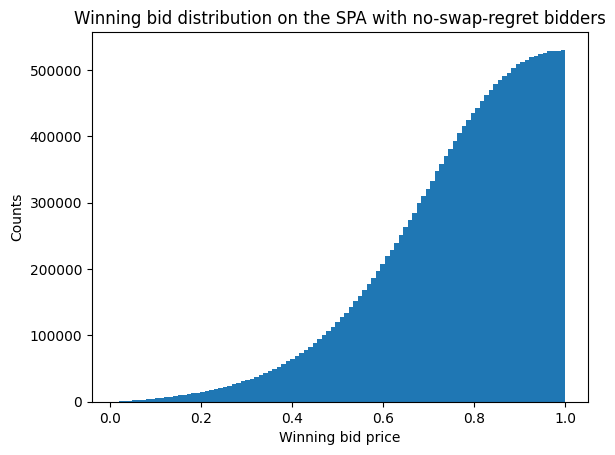

In [18]:
plt.hist(df_spa_bm['winning_bid'],bins=100)
plt.title(f'Winning bid distribution on the SPA with no-swap-regret bidders')
plt.xlabel("Winning bid price")
plt.ylabel("Counts")
# plt.savefig("winning_bid_bm.png")

In [8]:
df_spa_bm

,round,winner,winning_bid,payment,bid1,bid2,external_regret1,external_regret2,swap_regret1,swap_regret2
0,1,Bidder 2,0.96,0.38,0.38,0.96,0.040000,0.000000,0.040000,0.000000
1,2,Bidder 1,0.74,0.60,0.74,0.60,0.020000,0.000000,0.020000,0.000000
2,3,Bidder 1,0.16,0.16,0.16,0.16,0.153333,0.056667,0.153333,0.056667
3,4,Bidder 1,0.46,0.34,0.46,0.34,0.115000,0.052500,0.115000,0.052500
4,5,Bidder 2,0.66,0.15,0.15,0.66,0.160000,0.042000,0.160000,0.042000
...,...,...,...,...,...,...,...,...,...,...
19999995,19999996,Bidder 1,0.96,0.70,0.96,0.70,0.064824,0.029093,0.064824,0.029093
19999996,19999997,Bidder 1,0.89,0.69,0.89,0.69,0.064824,0.029093,0.064824,0.029093
19999997,19999998,Bidder 1,0.83,0.60,0.83,0.60,0.064824,0.029093,0.064824,0.029093
19999998,19999999,Bidder 2,0.80,0.65,0.65,0.80,0.064824,0.029093,0.064824,0.029093


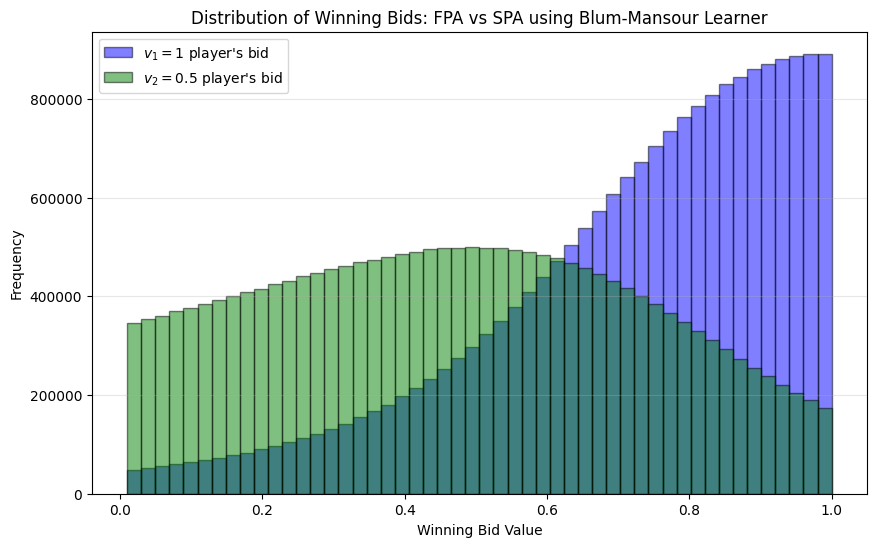

In [9]:
plt.figure(figsize=(10, 6))

# Plot FPA winning bids
plt.hist(df_spa_bm['bid1'], bins=50, alpha=0.5, label="$v_1=1$ player's bid", color='blue', edgecolor='black')

# Plot SPA winning bids
plt.hist(df_spa_bm['bid2'], bins=50, alpha=0.5, label="$v_2=0.5$ player's bid", color='green', edgecolor='black')

plt.title('Distribution of Winning Bids: FPA vs SPA using Blum-Mansour Learner')
plt.xlabel('Winning Bid Value')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

# SPA with different learning rate experiments

In [24]:
V = 100                  
v1 = V / V              
v2 = 50 / V      

T = 20000000
every = T / 20
etas = [1 / np.sqrt(t) for t in range(1, T + 1)]
etas2 = [0.1 / np.sqrt(t) for t in range(1, T + 1)]
df_spa_1 = simulate_auction(
    learning_rates=etas, 
    v1=v1, v2=v2, V=V, 
    auction_type='second', 
    algo1='MWU', 
    algo2='MWU', 
    every=every)

Round 0
Round 1000000
Round 2000000
Round 3000000
Round 4000000
Round 5000000
Round 6000000
Round 7000000
Round 8000000
Round 9000000
Round 10000000
Round 11000000
Round 12000000
Round 13000000
Round 14000000
Round 15000000
Round 16000000
Round 17000000
Round 18000000
Round 19000000


In [23]:
V = 100                  
v1 = V / V              
v2 = 50 / V      

T = 20000000
every = T / 20
etas = [5 / np.sqrt(t) for t in range(1, T + 1)]
etas2 = [1 / np.sqrt(t) for t in range(1, T + 1)]
df_spa = simulate_auction(
    learning_rates=etas, 
    v1=v1, v2=v2, V=V, 
    auction_type='second', 
    algo1='MWU', 
    algo2='MWU', 
    every=every,
    learning_rates_2=etas2)

Round 0
Round 1000000
Round 2000000
Round 3000000
Round 4000000
Round 5000000
Round 6000000
Round 7000000
Round 8000000
Round 9000000
Round 10000000
Round 11000000
Round 12000000
Round 13000000
Round 14000000
Round 15000000
Round 16000000
Round 17000000
Round 18000000
Round 19000000


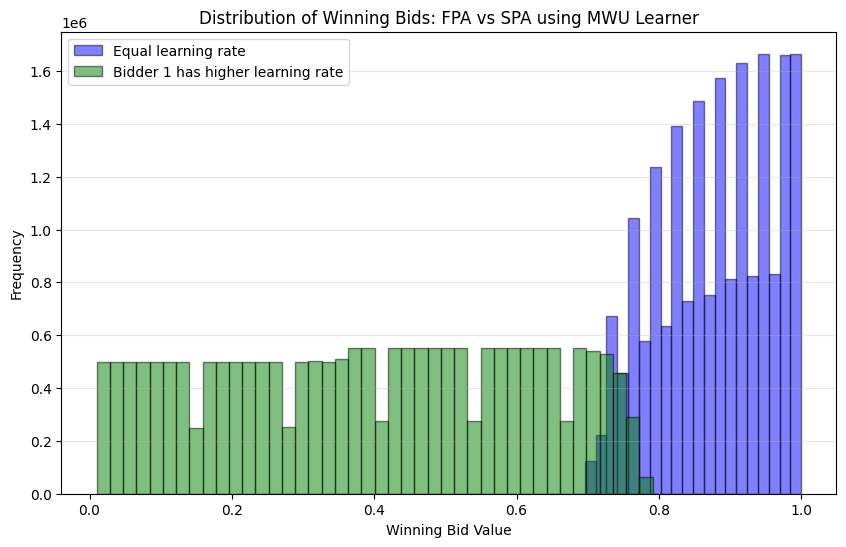

In [29]:
plt.figure(figsize=(10, 6))

# Plot FPA winning bids
plt.hist(df_spa_1['winning_bid'], bins=50, alpha=0.5, label="Equal learning rate", color='blue', edgecolor='black')

# Plot SPA winning bids
plt.hist(df_spa['bid2'], bins=50, alpha=0.5, label="Bidder 1 has higher learning rate", color='green', edgecolor='black')

plt.title('Distribution of Winning Bids: FPA vs SPA using MWU Learner')
plt.xlabel('Winning Bid Value')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

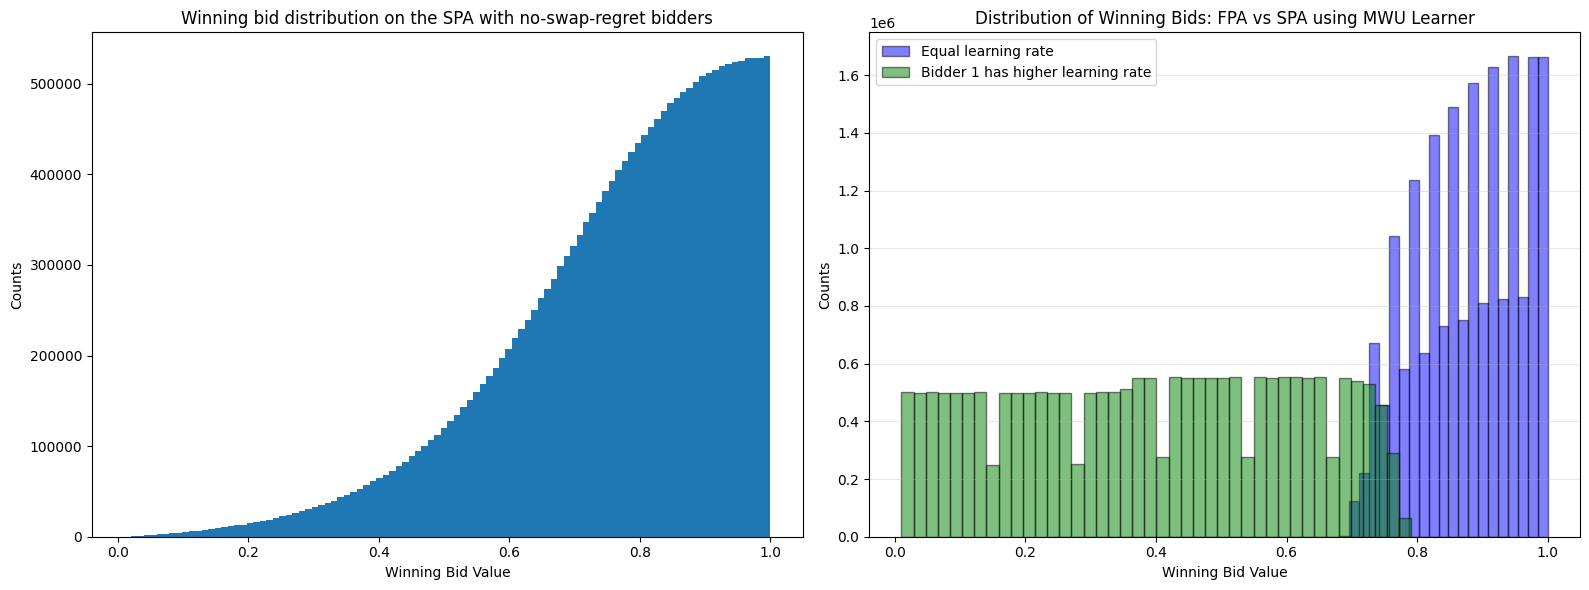

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left plot ---
axes[0].hist(df_spa_bm['winning_bid'], bins=100)
axes[0].set_title('Winning bid distribution on the SPA with no-swap-regret bidders')
axes[0].set_xlabel('Winning Bid Value')
axes[0].set_ylabel('Counts')

# --- Right plot ---
axes[1].hist(df_spa_1['winning_bid'], bins=50, alpha=0.5, label='Equal learning rate', color='blue', edgecolor='black')
axes[1].hist(df_spa['bid2'], bins=50, alpha=0.5, label='Bidder 1 has higher learning rate', color='green', edgecolor='black')
axes[1].set_title('Distribution of Winning Bids: FPA vs SPA using MWU Learner')
axes[1].set_xlabel('Winning Bid Value')
axes[1].set_ylabel('Counts')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("project.png")
plt.show()